In [2]:
import pandas as pd
from pathlib import Path

root_yawn = Path("../data/raw/yawn-data")

filas = []
for clase, carpeta in [("yawn", "yawn"), ("no_yawn", "no yawn")]:
    for p in (root_yawn / carpeta).iterdir():
        if p.is_file():
            filas.append({
                "ruta": str(p.relative_to(root_yawn)),
                "archivo": p.name,
                "clase": clase,
                "etiqueta": 1 if clase == "yawn" else 0,
            })

df_yawn = pd.DataFrame(filas)
print("Total de imágenes:", len(df_yawn))
print(df_yawn["clase"].value_counts())
df_yawn.head()

Total de imágenes: 5119
clase
no_yawn    2591
yawn       2528
Name: count, dtype: int64


,ruta,archivo,clase,etiqueta
0,yawn\1.jpg,1.jpg,yawn,1
1,yawn\10.jpg,10.jpg,yawn,1
2,yawn\100.jpg,100.jpg,yawn,1
3,yawn\1000.jpg,1000.jpg,yawn,1
4,yawn\1001.jpg,1001.jpg,yawn,1


In [3]:
from PIL import Image
import random

muestra = df_yawn.sample(10, random_state=1)
for _, fila in muestra.iterrows():
    with Image.open(root_yawn / fila["ruta"]) as img:
        print(f"{fila['clase']:8s} | {fila['archivo']:20s} | tamaño: {img.size} | modo: {img.mode}")

yawn     | 74.jpg               | tamaño: (53, 54) | modo: RGB
yawn     | 112.jpg              | tamaño: (57, 60) | modo: RGB
no_yawn  | 3459.jpg             | tamaño: (49, 40) | modo: RGB
yawn     | 1810.jpg             | tamaño: (61, 79) | modo: RGB
yawn     | 1223.jpg             | tamaño: (63, 76) | modo: RGB
no_yawn  | 3838.jpg             | tamaño: (100, 80) | modo: RGB
yawn     | 2525.jpg             | tamaño: (79, 85) | modo: RGB
yawn     | 816.jpg              | tamaño: (82, 101) | modo: RGB
no_yawn  | 3143.jpg             | tamaño: (120, 104) | modo: RGB
no_yawn  | 3569.jpg             | tamaño: (107, 87) | modo: RGB


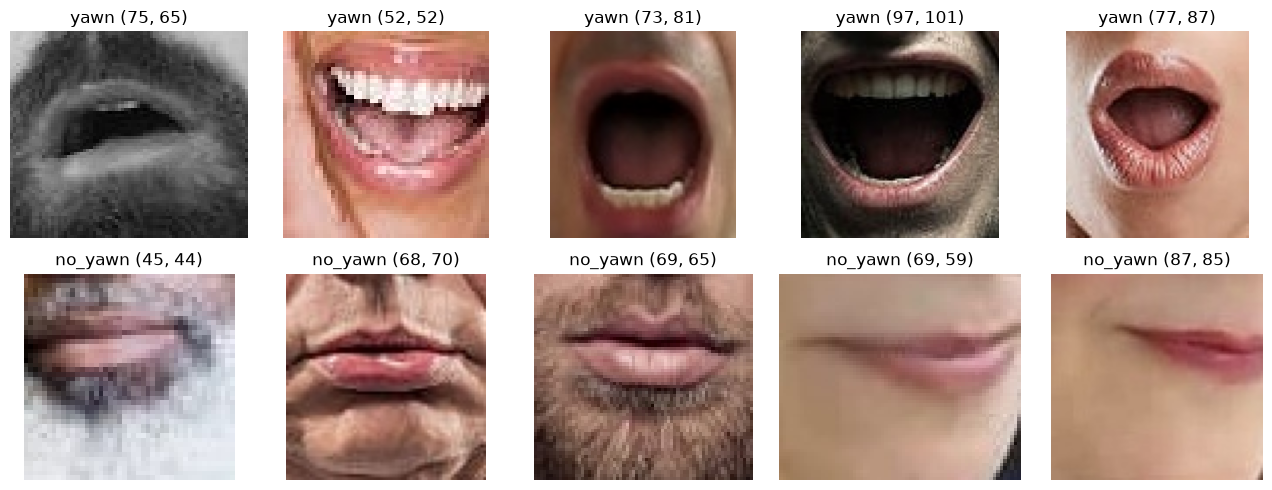

In [4]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for fila_idx, clase in enumerate(["yawn", "no_yawn"]):
    ejemplos = df_yawn[df_yawn["clase"] == clase].sample(5, random_state=2)
    for col, (_, fila) in enumerate(ejemplos.iterrows()):
        img = Image.open(root_yawn / fila["ruta"]).convert("RGB")
        axes[fila_idx, col].imshow(img)
        axes[fila_idx, col].set_title(f"{clase} {img.size}")
        axes[fila_idx, col].axis("off")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# Primero separamos test (15%), luego dividimos el resto en train/val
train_val, test = train_test_split(
    df_yawn, test_size=0.15, stratify=df_yawn["etiqueta"], random_state=42
)
train, val = train_test_split(
    train_val, test_size=0.15/0.85, stratify=train_val["etiqueta"], random_state=42
)

train = train.copy(); train["split"] = "train"
val = val.copy(); val["split"] = "val"
test = test.copy(); test["split"] = "test"

df_yawn_split = pd.concat([train, val, test]).reset_index(drop=True)

print(pd.crosstab(df_yawn_split["split"], df_yawn_split["clase"], margins=True))

clase  no_yawn  yawn   All
split                     
test       389   379   768
train     1813  1770  3583
val        389   379   768
All       2591  2528  5119


In [6]:
Path("../results").mkdir(exist_ok=True)
df_yawn_split.to_csv("../results/yawn_metadata.csv", index=False)
print("Guardado en results/yawn_metadata.csv")

Guardado en results/yawn_metadata.csv


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class BocaDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        img = Image.open(self.root_dir / fila["ruta"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        etiqueta = fila["etiqueta"]  # 1 = yawn, 0 = no_yawn
        return img, etiqueta

media = [0.485, 0.456, 0.406]
desv = [0.229, 0.224, 0.225]

train_tf_yawn = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

eval_tf_yawn = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(media, desv),
])

train_ds_yawn = BocaDataset(df_yawn_split[df_yawn_split.split == "train"], root_yawn, train_tf_yawn)
val_ds_yawn   = BocaDataset(df_yawn_split[df_yawn_split.split == "val"], root_yawn, eval_tf_yawn)
test_ds_yawn  = BocaDataset(df_yawn_split[df_yawn_split.split == "test"], root_yawn, eval_tf_yawn)

train_loader_yawn = DataLoader(train_ds_yawn, batch_size=64, shuffle=True, num_workers=0)
val_loader_yawn   = DataLoader(val_ds_yawn, batch_size=64, shuffle=False, num_workers=0)
test_loader_yawn  = DataLoader(test_ds_yawn, batch_size=64, shuffle=False, num_workers=0)

print("train:", len(train_ds_yawn), "| val:", len(val_ds_yawn), "| test:", len(test_ds_yawn))

train: 3583 | val: 768 | test: 768


In [8]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando:", device)

def entrenar_una_epoca(modelo, loader, criterio, optimizador, device):
    modelo.train()
    perdida_total = 0.0
    preds_todas, labels_todas = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels_f = labels.float().unsqueeze(1).to(device)
        optimizador.zero_grad()
        salidas = modelo(imgs)
        perdida = criterio(salidas, labels_f)
        perdida.backward()
        optimizador.step()
        perdida_total += perdida.item() * imgs.size(0)
        preds = (torch.sigmoid(salidas) > 0.5).int().cpu().flatten()
        preds_todas.extend(preds.tolist())
        labels_todas.extend(labels.tolist())
    return perdida_total / len(loader.dataset), accuracy_score(labels_todas, preds_todas)

def evaluar(modelo, loader, criterio, device):
    modelo.eval()
    perdida_total = 0.0
    preds_todas, labels_todas = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels_f = labels.float().unsqueeze(1).to(device)
            salidas = modelo(imgs)
            perdida = criterio(salidas, labels_f)
            perdida_total += perdida.item() * imgs.size(0)
            preds = (torch.sigmoid(salidas) > 0.5).int().cpu().flatten()
            preds_todas.extend(preds.tolist())
            labels_todas.extend(labels.tolist())
    return perdida_total / len(loader.dataset), accuracy_score(labels_todas, preds_todas)

print("Funciones listas.")

Usando: cuda
Funciones listas.


In [9]:
modelo_yawn = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
for parametro in modelo_yawn.features.parameters():
    parametro.requires_grad = False
modelo_yawn.classifier[1] = nn.Linear(modelo_yawn.last_channel, 1)
modelo_yawn = modelo_yawn.to(device)

criterio = nn.BCEWithLogitsLoss()
optimizador_yawn = optim.Adam(modelo_yawn.classifier.parameters(), lr=1e-3)

N_EPOCAS = 5
mejor_val_acc_yawn = 0.0
historial_yawn_e1 = []

for epoca in range(1, N_EPOCAS + 1):
    inicio = time.time()
    train_perdida, train_acc = entrenar_una_epoca(modelo_yawn, train_loader_yawn, criterio, optimizador_yawn, device)
    val_perdida, val_acc = evaluar(modelo_yawn, val_loader_yawn, criterio, device)
    duracion = time.time() - inicio

    historial_yawn_e1.append({"epoca": epoca, "train_perdida": train_perdida, "train_acc": train_acc,
                               "val_perdida": val_perdida, "val_acc": val_acc, "duracion_seg": duracion})
    print(f"[Yawn-Etapa1] Época {epoca}/{N_EPOCAS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | {duracion:.1f}s")

    if val_acc > mejor_val_acc_yawn:
        mejor_val_acc_yawn = val_acc
        torch.save(modelo_yawn.state_dict(), "../models/mobilenetv2_yawn_etapa1.pth")
        print(f"  → Nuevo mejor modelo guardado (val_acc={val_acc:.4f})")

print("\nEtapa 1 (yawn) terminada. Mejor val_acc:", mejor_val_acc_yawn)

[Yawn-Etapa1] Época 1/5 | train_acc=0.7946 | val_acc=0.9310 | 48.1s
  → Nuevo mejor modelo guardado (val_acc=0.9310)
[Yawn-Etapa1] Época 2/5 | train_acc=0.9238 | val_acc=0.9466 | 16.8s
  → Nuevo mejor modelo guardado (val_acc=0.9466)
[Yawn-Etapa1] Época 3/5 | train_acc=0.9408 | val_acc=0.9518 | 14.6s
  → Nuevo mejor modelo guardado (val_acc=0.9518)
[Yawn-Etapa1] Época 4/5 | train_acc=0.9400 | val_acc=0.9479 | 14.6s
[Yawn-Etapa1] Época 5/5 | train_acc=0.9464 | val_acc=0.9518 | 14.7s

Etapa 1 (yawn) terminada. Mejor val_acc: 0.9518229166666666


In [10]:
modelo_yawn_ft = models.mobilenet_v2(weights=None)
modelo_yawn_ft.classifier[1] = nn.Linear(modelo_yawn_ft.last_channel, 1)
modelo_yawn_ft.load_state_dict(torch.load("../models/mobilenetv2_yawn_etapa1.pth"))
modelo_yawn_ft = modelo_yawn_ft.to(device)

for parametro in modelo_yawn_ft.parameters():
    parametro.requires_grad = False
for bloque in modelo_yawn_ft.features[-3:]:
    for parametro in bloque.parameters():
        parametro.requires_grad = True
for parametro in modelo_yawn_ft.classifier.parameters():
    parametro.requires_grad = True

entrenables = sum(p.numel() for p in modelo_yawn_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in modelo_yawn_ft.parameters())
print(f"Parámetros entrenables: {entrenables:,} de {total:,} ({100*entrenables/total:.1f}%)")

optimizador_yawn_ft = optim.Adam(filter(lambda p: p.requires_grad, modelo_yawn_ft.parameters()), lr=1e-5)

mejor_val_acc_yawn_ft = 0.0
historial_yawn_ft = []

for epoca in range(1, N_EPOCAS + 1):
    inicio = time.time()
    train_perdida, train_acc = entrenar_una_epoca(modelo_yawn_ft, train_loader_yawn, criterio, optimizador_yawn_ft, device)
    val_perdida, val_acc = evaluar(modelo_yawn_ft, val_loader_yawn, criterio, device)
    duracion = time.time() - inicio

    historial_yawn_ft.append({"epoca": epoca, "train_perdida": train_perdida, "train_acc": train_acc,
                               "val_perdida": val_perdida, "val_acc": val_acc, "duracion_seg": duracion})
    print(f"[Yawn-Etapa2] Época {epoca}/{N_EPOCAS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | {duracion:.1f}s")

    if val_acc > mejor_val_acc_yawn_ft:
        mejor_val_acc_yawn_ft = val_acc
        torch.save(modelo_yawn_ft.state_dict(), "../models/mobilenetv2_yawn_finetuned.pth")
        print(f"  → Nuevo mejor modelo (fine-tuned) guardado (val_acc={val_acc:.4f})")

print("\nEtapa 2 (yawn) terminada. Mejor val_acc:", mejor_val_acc_yawn_ft)

Parámetros entrenables: 1,207,361 de 2,225,153 (54.3%)
[Yawn-Etapa2] Época 1/5 | train_acc=0.9433 | val_acc=0.9609 | 13.2s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9609)
[Yawn-Etapa2] Época 2/5 | train_acc=0.9567 | val_acc=0.9648 | 14.6s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9648)
[Yawn-Etapa2] Época 3/5 | train_acc=0.9665 | val_acc=0.9674 | 15.5s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9674)
[Yawn-Etapa2] Época 4/5 | train_acc=0.9665 | val_acc=0.9688 | 15.3s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9688)
[Yawn-Etapa2] Época 5/5 | train_acc=0.9682 | val_acc=0.9714 | 15.5s
  → Nuevo mejor modelo (fine-tuned) guardado (val_acc=0.9714)

Etapa 2 (yawn) terminada. Mejor val_acc: 0.9713541666666666


In [11]:
def evaluar_en_test_yawn(modelo, loader, device):
    modelo.eval()
    preds, labels_todas, probas = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            salidas = modelo(imgs.to(device))
            p = torch.sigmoid(salidas).cpu().flatten()
            preds.extend((p > 0.5).int().tolist())
            probas.extend(p.tolist())
            labels_todas.extend(labels.tolist())
    return labels_todas, preds, probas

labels_yawn, preds_yawn, probas_yawn = evaluar_en_test_yawn(modelo_yawn_ft, test_loader_yawn, device)

print("Exactitud en test:", accuracy_score(labels_yawn, preds_yawn))
print("AUC-ROC en test:", roc_auc_score(labels_yawn, probas_yawn))
print()
print(classification_report(labels_yawn, preds_yawn, target_names=["no_yawn", "yawn"]))
print()
print("Matriz de confusión:")
print(confusion_matrix(labels_yawn, preds_yawn))

Exactitud en test: 0.9778645833333334
AUC-ROC en test: 0.9980533266409373

              precision    recall  f1-score   support

     no_yawn       0.97      0.98      0.98       389
        yawn       0.98      0.97      0.98       379

    accuracy                           0.98       768
   macro avg       0.98      0.98      0.98       768
weighted avg       0.98      0.98      0.98       768


Matriz de confusión:
[[382   7]
 [ 10 369]]


In [12]:
# Guardar historiales
pd.DataFrame(historial_yawn_e1).to_csv("../results/historial_yawn_etapa1.csv", index=False)
pd.DataFrame(historial_yawn_ft).to_csv("../results/historial_yawn_etapa2.csv", index=False)

comparacion_yawn = pd.DataFrame({
    "etapa": ["Etapa 1 (clasificador)", "Etapa 2 (fine-tuning)"],
    "val_acc": [mejor_val_acc_yawn, mejor_val_acc_yawn_ft],
    "exactitud_test": [None, accuracy_score(labels_yawn, preds_yawn)],
    "auc_roc_test": [None, roc_auc_score(labels_yawn, probas_yawn)],
})
comparacion_yawn.to_csv("../results/comparacion_yawn_etapas.csv", index=False)
print(comparacion_yawn)

# Exportar a ONNX
modelo_yawn_ft.eval()
entrada_ejemplo = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    modelo_yawn_ft,
    entrada_ejemplo,
    "../models/mobilenetv2_yawn.onnx",
    input_names=["entrada"],
    output_names=["salida"],
    dynamic_axes={"entrada": {0: "batch"}, "salida": {0: "batch"}},
    opset_version=17,
    dynamo=False,
)
print("Modelo de bostezo exportado a ../models/mobilenetv2_yawn.onnx")

                    etapa   val_acc  exactitud_test  auc_roc_test
0  Etapa 1 (clasificador)  0.951823             NaN           NaN
1   Etapa 2 (fine-tuning)  0.971354        0.977865      0.998053


C:\Users\FIORELLA\AppData\Local\Temp\ipykernel_28860\2997592631.py:18: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Modelo de bostezo exportado a ../models/mobilenetv2_yawn.onnx


In [15]:
import onnxruntime as ort
import numpy as np

print("onnxruntime y numpy importados correctamente.")

onnxruntime y numpy importados correctamente.


In [16]:
sesion_yawn = ort.InferenceSession("../models/mobilenetv2_yawn.onnx", providers=["CPUExecutionProvider"])
nombre_entrada_yawn = sesion_yawn.get_inputs()[0].name

imgs, labels = next(iter(test_loader_yawn))
modelo_yawn_ft.eval()
with torch.no_grad():
    salida_pt = modelo_yawn_ft(imgs.to(device))
    probas_pt = torch.sigmoid(salida_pt).cpu().numpy().flatten()

entradas_onnx = {nombre_entrada_yawn: imgs.numpy()}
salida_onnx = sesion_yawn.run(None, entradas_onnx)[0]
probas_onnx = 1 / (1 + np.exp(-salida_onnx.flatten()))

print("Diferencia máxima:", np.abs(probas_pt - probas_onnx).max().round(6))

Diferencia máxima: 0.000997


In [17]:
# En 05_yawn_entrenamiento.ipynb, con df_yawn ya cargado
import hashlib

modos, tamanos = [], []
hashes = {}
for _, fila in df_yawn.iterrows():
    with Image.open(root_yawn / fila["ruta"]) as img:
        modos.append(img.mode)
        tamanos.append(img.size)
    hashes.setdefault(hashlib.md5((root_yawn / fila["ruta"]).read_bytes()).hexdigest(), []).append(fila["archivo"])

modos_s = pd.Series(modos).value_counts()
print("Proporción color vs gris:")
print(modos_s, "\n", (modos_s/len(df_yawn)*100).round(1))

anchos = [t[0] for t in tamanos]; altos = [t[1] for t in tamanos]
print(f"\nRango de resolución: {min(anchos)}x{min(altos)} a {max(anchos)}x{max(altos)}")

duplicados = {h: a for h, a in hashes.items() if len(a) > 1}
print(f"\nImágenes duplicadas exactas: {sum(len(v) for v in duplicados.values())} en {len(duplicados)} grupos")

Proporción color vs gris:
RGB    5119
Name: count, dtype: int64 
 RGB    100.0
Name: count, dtype: float64

Rango de resolución: 20x10 a 549x396

Imágenes duplicadas exactas: 1283 en 566 grupos


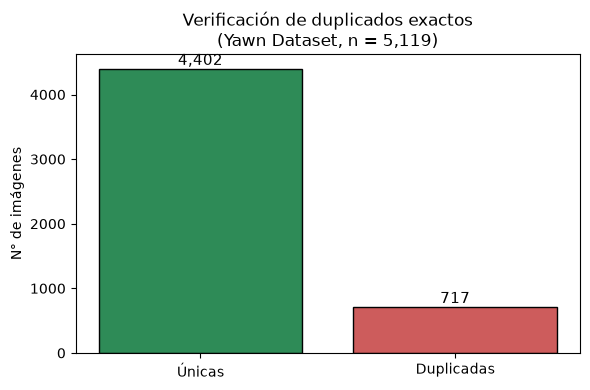

In [18]:
total_yawn = len(df_yawn)
n_duplicados = sum(len(v) - 1 for v in duplicados.values())
n_unicas = total_yawn - n_duplicados

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["Únicas", "Duplicadas"], [n_unicas, n_duplicados],
                 color=["seagreen", "indianred"], edgecolor="black")
ax.set_title(f"Verificación de duplicados exactos\n(Yawn Dataset, n = {total_yawn:,})")
ax.set_ylabel("N° de imágenes")

for barra, valor in zip(barras, [n_unicas, n_duplicados]):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
            f"{valor:,}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("../results/fig_duplicados_yawn.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Mapear cada archivo a su partición
archivo_a_split = dict(zip(df_yawn_split["archivo"], df_yawn_split["split"]))

grupos_cruzados = 0
imagenes_en_fuga = 0
for h, archivos in duplicados.items():
    splits_de_este_grupo = set(archivo_a_split[a] for a in archivos)
    if len(splits_de_este_grupo) > 1:
        grupos_cruzados += 1
        imagenes_en_fuga += len(archivos)

print("Grupos de duplicados que caen en MÁS de una partición:", grupos_cruzados)
print("Imágenes involucradas en esa fuga cruzada:", imagenes_en_fuga)
print("Grupos de duplicados que caen en LA MISMA partición (sin fuga):", len(duplicados) - grupos_cruzados)

Grupos de duplicados que caen en MÁS de una partición: 290
Imágenes involucradas en esa fuga cruzada: 707
Grupos de duplicados que caen en LA MISMA partición (sin fuga): 276


In [21]:
# Quedarnos con una sola copia por cada grupo de duplicados (la primera)
archivos_a_conservar = set()
for h, archivos in hashes.items():
    archivos_a_conservar.add(archivos[0])  # se conserva solo el primero de cada grupo

df_yawn_dedup = df_yawn[df_yawn["archivo"].isin(archivos_a_conservar)].reset_index(drop=True)

print("Antes de deduplicar:", len(df_yawn))
print("Después de deduplicar:", len(df_yawn_dedup))
print(df_yawn_dedup["clase"].value_counts())

Antes de deduplicar: 5119
Después de deduplicar: 4402
clase
no_yawn    2276
yawn       2126
Name: count, dtype: int64


In [3]:
import pandas as pd
from pathlib import Path

root_yawn = Path("../data/raw/yawn-data")

ruta_metadata = Path("../results/yawn_metadata_dedup.csv")

if not ruta_metadata.exists():
    raise FileNotFoundError(
        "No se encontró ../results/yawn_metadata_dedup.csv"
    )

df_yawn_split_v2 = pd.read_csv(ruta_metadata)

print("Metadata deduplicada cargada correctamente.")
print("Total:", len(df_yawn_split_v2))
print()

print(
    pd.crosstab(
        df_yawn_split_v2["split"],
        df_yawn_split_v2["clase"],
        margins=True
    )
)

Metadata deduplicada cargada correctamente.
Total: 4402

clase  no_yawn  yawn   All
split                     
test       342   319   661
train     1592  1488  3080
val        342   319   661
All       2276  2126  4402


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


class BocaDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        fila = self.df.iloc[idx]

        img = Image.open(
            self.root_dir / fila["ruta"]
        ).convert("RGB")

        if self.transform:
            img = self.transform(img)

        etiqueta = int(fila["etiqueta"])

        return img, etiqueta

In [ ]:
media = [0.485, 0.456, 0.406]
desv = [0.229, 0.224, 0.225]


train_tf_yawn = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        media,
        desv
    ),
])


eval_tf_yawn = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        media,
        desv
    ),
])

In [ ]:
train_ds_yawn_v2 = BocaDataset(
    df_yawn_split_v2[
        df_yawn_split_v2["split"] == "train"
    ],
    root_yawn,
    train_tf_yawn
)

val_ds_yawn_v2 = BocaDataset(
    df_yawn_split_v2[
        df_yawn_split_v2["split"] == "val"
    ],
    root_yawn,
    eval_tf_yawn
)

test_ds_yawn_v2 = BocaDataset(
    df_yawn_split_v2[
        df_yawn_split_v2["split"] == "test"
    ],
    root_yawn,
    eval_tf_yawn
)

In [7]:
train_loader_yawn_v2 = DataLoader(
    train_ds_yawn_v2,
    batch_size=64,
    shuffle=True,
    num_workers=0
)


val_loader_yawn_v2 = DataLoader(
    val_ds_yawn_v2,
    batch_size=64,
    shuffle=False,
    num_workers=0
)


test_loader_yawn_v2 = DataLoader(
    test_ds_yawn_v2,
    batch_size=64,
    shuffle=False,
    num_workers=0
)


print("Train:", len(train_ds_yawn_v2))
print("Val:", len(val_ds_yawn_v2))
print("Test:", len(test_ds_yawn_v2))

print(
    "Total:",
    len(train_ds_yawn_v2)
    + len(val_ds_yawn_v2)
    + len(test_ds_yawn_v2)
)

Train: 3080
Val: 661
Test: 661
Total: 4402


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score
import numpy as np
import random
import time

# Semilla para reproducibilidad
SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMILLA)

# Dispositivo para ENTRENAMIENTO
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo de entrenamiento:", device)
print("Semilla:", SEMILLA)

Dispositivo de entrenamiento: cuda
Semilla: 42


In [9]:
def entrenar_una_epoca(modelo, loader, criterio, optimizador, device):

    modelo.train()

    perdida_total = 0.0
    preds_todas = []
    labels_todas = []

    for imgs, labels in loader:

        imgs = imgs.to(device)

        labels_f = (
            labels
            .float()
            .unsqueeze(1)
            .to(device)
        )

        optimizador.zero_grad()

        salidas = modelo(imgs)

        perdida = criterio(
            salidas,
            labels_f
        )

        perdida.backward()

        optimizador.step()

        perdida_total += (
            perdida.item() * imgs.size(0)
        )

        probas = torch.sigmoid(salidas)

        preds = (
            probas > 0.5
        ).int().cpu().flatten()

        preds_todas.extend(
            preds.tolist()
        )

        labels_todas.extend(
            labels.tolist()
        )

    perdida_promedio = (
        perdida_total /
        len(loader.dataset)
    )

    exactitud = accuracy_score(
        labels_todas,
        preds_todas
    )

    return perdida_promedio, exactitud

In [10]:
def evaluar(
    modelo,
    loader,
    criterio,
    device
):

    modelo.eval()

    perdida_total = 0.0
    preds_todas = []
    labels_todas = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(device)

            labels_f = (
                labels
                .float()
                .unsqueeze(1)
                .to(device)
            )

            salidas = modelo(imgs)

            perdida = criterio(
                salidas,
                labels_f
            )

            perdida_total += (
                perdida.item()
                * imgs.size(0)
            )

            probas = torch.sigmoid(
                salidas
            )

            preds = (
                probas > 0.5
            ).int().cpu().flatten()

            preds_todas.extend(
                preds.tolist()
            )

            labels_todas.extend(
                labels.tolist()
            )

    perdida_promedio = (
        perdida_total /
        len(loader.dataset)
    )

    exactitud = accuracy_score(
        labels_todas,
        preds_todas
    )

    return perdida_promedio, exactitud


print("Funciones de entrenamiento y evaluación listas.")

Funciones de entrenamiento y evaluación listas.


In [11]:
# MobileNetV2 preentrenada en ImageNet
modelo_yawn_v2 = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)

# Congelar extractor de características
for parametro in modelo_yawn_v2.features.parameters():
    parametro.requires_grad = False

# Clasificación binaria
modelo_yawn_v2.classifier[1] = nn.Linear(
    modelo_yawn_v2.last_channel,
    1
)

modelo_yawn_v2 = modelo_yawn_v2.to(device)

# Función de pérdida
criterio_yawn_v2 = nn.BCEWithLogitsLoss()

# En Etapa 1 solamente se entrena el clasificador
optimizador_yawn_v2 = optim.Adam(
    modelo_yawn_v2.classifier.parameters(),
    lr=1e-3
)

N_EPOCAS = 5

mejor_val_acc_yawn_v2 = 0.0
historial_yawn_v2_e1 = []

print("Modelo T2 deduplicado preparado.")

Modelo T2 deduplicado preparado.


In [ ]:
for epoca in range(1, N_EPOCAS + 1):

    inicio = time.time()
    train_perdida, train_acc = entrenar_una_epoca(
        modelo_yawn_v2,
        train_loader_yawn_v2,
        criterio_yawn_v2,
        optimizador_yawn_v2,
        device
    )

    val_perdida, val_acc = evaluar(
        modelo_yawn_v2,
        val_loader_yawn_v2,
        criterio_yawn_v2,
        device
    )

    duracion = time.time() - inicio
    historial_yawn_v2_e1.append({
        "epoca": epoca,
        "train_perdida": train_perdida,
        "train_acc": train_acc,
        "val_perdida": val_perdida,
        "val_acc": val_acc,
        "duracion_seg": duracion
    })

    print(
        f"[T2 limpio - Etapa 1] "
        f"Época {epoca}/{N_EPOCAS} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"{duracion:.1f}s"
    )

    if val_acc > mejor_val_acc_yawn_v2:
        mejor_val_acc_yawn_v2 = val_acc
        torch.save(
            modelo_yawn_v2.state_dict(),
            "../models/mobilenetv2_yawn_dedup_etapa1.pth"
        )
        print(
            "  → Nuevo mejor modelo guardado "
            f"(val_acc={val_acc:.4f})"
        )
print(
    "\nEtapa 1 terminada."
)
print(
    "Mejor val_acc:",
    mejor_val_acc_yawn_v2
)

[T2 limpio - Etapa 1] Época 1/5 | train_acc=0.8071 | val_acc=0.9304 | 29.0s
  → Nuevo mejor modelo guardado (val_acc=0.9304)
[T2 limpio - Etapa 1] Época 2/5 | train_acc=0.9256 | val_acc=0.9470 | 11.3s
  → Nuevo mejor modelo guardado (val_acc=0.9470)
[T2 limpio - Etapa 1] Época 3/5 | train_acc=0.9331 | val_acc=0.9319 | 12.9s
[T2 limpio - Etapa 1] Época 4/5 | train_acc=0.9425 | val_acc=0.9516 | 12.0s
  → Nuevo mejor modelo guardado (val_acc=0.9516)
[T2 limpio - Etapa 1] Época 5/5 | train_acc=0.9334 | val_acc=0.9546 | 12.1s
  → Nuevo mejor modelo guardado (val_acc=0.9546)

Etapa 1 terminada.
Mejor val_acc: 0.9546142208774584


In [13]:
# Reconstruir el modelo y cargar el mejor checkpoint de la Etapa 1
modelo_yawn_v2_ft = models.mobilenet_v2(weights=None)

modelo_yawn_v2_ft.classifier[1] = nn.Linear(
    modelo_yawn_v2_ft.last_channel,
    1
)

modelo_yawn_v2_ft.load_state_dict(
    torch.load(
        "../models/mobilenetv2_yawn_dedup_etapa1.pth",
        map_location=device
    )
)

modelo_yawn_v2_ft = modelo_yawn_v2_ft.to(device)

# Congelar todo el modelo
for parametro in modelo_yawn_v2_ft.parameters():
    parametro.requires_grad = False

# Descongelar los últimos 3 bloques de features
for bloque in modelo_yawn_v2_ft.features[-3:]:
    for parametro in bloque.parameters():
        parametro.requires_grad = True

# Descongelar clasificador
for parametro in modelo_yawn_v2_ft.classifier.parameters():
    parametro.requires_grad = True

# Comprobar parámetros entrenables
entrenables = sum(
    p.numel()
    for p in modelo_yawn_v2_ft.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in modelo_yawn_v2_ft.parameters()
)

print(
    f"Parámetros entrenables: {entrenables:,} "
    f"de {total:,} "
    f"({100 * entrenables / total:.1f}%)"
)

# Learning rate menor para fine-tuning
optimizador_yawn_v2_ft = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        modelo_yawn_v2_ft.parameters()
    ),
    lr=1e-5
)

mejor_val_acc_yawn_v2_ft = 0.0
historial_yawn_v2_ft = []

Parámetros entrenables: 1,207,361 de 2,225,153 (54.3%)


In [14]:
for epoca in range(1, N_EPOCAS + 1):

    inicio = time.time()
    train_perdida, train_acc = entrenar_una_epoca(
        modelo_yawn_v2_ft,
        train_loader_yawn_v2,
        criterio_yawn_v2,
        optimizador_yawn_v2_ft,
        device
    )

    val_perdida, val_acc = evaluar(
        modelo_yawn_v2_ft,
        val_loader_yawn_v2,
        criterio_yawn_v2,
        device
    )

    duracion = time.time() - inicio
    historial_yawn_v2_ft.append({
        "epoca": epoca,
        "train_perdida": train_perdida,
        "train_acc": train_acc,
        "val_perdida": val_perdida,
        "val_acc": val_acc,
        "duracion_seg": duracion
    })

    print(
        f"[T2 limpio - Etapa 2] "
        f"Época {epoca}/{N_EPOCAS} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"{duracion:.1f}s"
    )

    if val_acc > mejor_val_acc_yawn_v2_ft:
        mejor_val_acc_yawn_v2_ft = val_acc
        torch.save(
            modelo_yawn_v2_ft.state_dict(),
            "../models/mobilenetv2_yawn_dedup_finetuned.pth"
        )
        print(
            "  → Nuevo mejor modelo fine-tuned guardado "
            f"(val_acc={val_acc:.4f})"
        )
        
print("\nEtapa 2 terminada.")
print(
    "Mejor val_acc:",
    mejor_val_acc_yawn_v2_ft
)

[T2 limpio - Etapa 2] Época 1/5 | train_acc=0.9513 | val_acc=0.9622 | 14.6s
  → Nuevo mejor modelo fine-tuned guardado (val_acc=0.9622)
[T2 limpio - Etapa 2] Época 2/5 | train_acc=0.9633 | val_acc=0.9667 | 13.0s
  → Nuevo mejor modelo fine-tuned guardado (val_acc=0.9667)
[T2 limpio - Etapa 2] Época 3/5 | train_acc=0.9630 | val_acc=0.9697 | 12.5s
  → Nuevo mejor modelo fine-tuned guardado (val_acc=0.9697)
[T2 limpio - Etapa 2] Época 4/5 | train_acc=0.9734 | val_acc=0.9713 | 12.5s
  → Nuevo mejor modelo fine-tuned guardado (val_acc=0.9713)
[T2 limpio - Etapa 2] Época 5/5 | train_acc=0.9731 | val_acc=0.9697 | 12.0s

Etapa 2 terminada.
Mejor val_acc: 0.9712556732223904


In [15]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Cargar el MEJOR modelo de la Etapa 2
modelo_yawn_final = models.mobilenet_v2(weights=None)

modelo_yawn_final.classifier[1] = nn.Linear(
    modelo_yawn_final.last_channel,
    1
)

modelo_yawn_final.load_state_dict(
    torch.load(
        "../models/mobilenetv2_yawn_dedup_finetuned.pth",
        map_location=device
    )
)

modelo_yawn_final = modelo_yawn_final.to(device)
modelo_yawn_final.eval()

print("Mejor modelo T2 limpio cargado correctamente.")

Mejor modelo T2 limpio cargado correctamente.


In [ ]:
def evaluar_test_yawn_final(modelo, loader, device):

    modelo.eval()
    labels_todas = []
    preds_todas = []
    probas_todas = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            salidas = modelo(imgs)

            # 1 = yawn, 0 = no_yawn
            probas = torch.sigmoid(
                salidas
            ).cpu().flatten()
            preds = (
                probas >= 0.5
            ).int()
            labels_todas.extend(
                labels.tolist()
            )
            preds_todas.extend(
                preds.tolist()
            )
            probas_todas.extend(
                probas.tolist()
            )
    return (
        labels_todas,
        preds_todas,
        probas_todas
    )

In [17]:
labels_yawn_final, preds_yawn_final, probas_yawn_final = (
    evaluar_test_yawn_final(
        modelo_yawn_final,
        test_loader_yawn_v2,
        device
    )
)

accuracy_final = accuracy_score(
    labels_yawn_final,
    preds_yawn_final
)

auc_final = roc_auc_score(
    labels_yawn_final,
    probas_yawn_final
)

print("=== T2 FINAL - YAWN DATASET DEDUPLICADO ===")
print(f"Imágenes de test: {len(labels_yawn_final)}")
print(f"Exactitud: {accuracy_final:.4f} ({accuracy_final*100:.2f}%)")
print(f"AUC-ROC: {auc_final:.4f}")

print("\nReporte por clase:")
print(
    classification_report(
        labels_yawn_final,
        preds_yawn_final,
        target_names=[
            "no_yawn",
            "yawn"
        ],
        digits=4
    )
)

print("Matriz de confusión:")
print(
    confusion_matrix(
        labels_yawn_final,
        preds_yawn_final
    )
)

=== T2 FINAL - YAWN DATASET DEDUPLICADO ===
Imágenes de test: 661
Exactitud: 0.9697 (96.97%)
AUC-ROC: 0.9928

Reporte por clase:
              precision    recall  f1-score   support

     no_yawn     0.9708    0.9708    0.9708       342
        yawn     0.9687    0.9687    0.9687       319

    accuracy                         0.9697       661
   macro avg     0.9697    0.9697    0.9697       661
weighted avg     0.9697    0.9697    0.9697       661

Matriz de confusión:
[[332  10]
 [ 10 309]]


In [18]:
modelo_yawn_final.eval()

entrada_ejemplo = torch.randn(
    1, 3, 224, 224,
    device=device
)

ruta_onnx_yawn_final = "../models/mobilenetv2_yawn_dedup.onnx"

torch.onnx.export(
    modelo_yawn_final,
    entrada_ejemplo,
    ruta_onnx_yawn_final,
    input_names=["entrada"],
    output_names=["salida"],
    dynamic_axes={
        "entrada": {0: "batch"},
        "salida": {0: "batch"}
    },
    opset_version=17,
    dynamo=False
)

print("T2 final exportado a:")
print(ruta_onnx_yawn_final)

C:\Users\FIORELLA\AppData\Local\Temp\ipykernel_11192\754587731.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


T2 final exportado a:
../models/mobilenetv2_yawn_dedup.onnx


In [19]:
from pathlib import Path

print(
    Path("../models/mobilenetv2_yawn_dedup.onnx").exists()
)

True


In [3]:
from pathlib import Path

base = Path("..")
extensiones = {".jpg", ".jpeg", ".png", ".bmp"}

candidatas = []

for carpeta in base.rglob("*"):
    if carpeta.is_dir():
        nombre = carpeta.name.lower()
        if "yawn" in nombre or "bostezo" in nombre:
            cantidad = sum(
                1 for p in carpeta.rglob("*")
                if p.is_file() and p.suffix.lower() in extensiones
            )
            if cantidad > 0:
                candidatas.append((str(carpeta), cantidad))

print("=== POSIBLES CARPETAS DEL YAWN DATASET ===")

for ruta, cantidad in sorted(
    candidatas,
    key=lambda x: x[1],
    reverse=True
):
    print(cantidad, "imágenes ->", ruta)

=== POSIBLES CARPETAS DEL YAWN DATASET ===
5119 imágenes -> ..\data\raw\yawn-data
2591 imágenes -> ..\data\raw\yawn-data\no yawn
2528 imágenes -> ..\data\raw\yawn-data\yawn


In [4]:
from pathlib import Path
from PIL import Image
import numpy as np

RUTA_YAWN = Path("../data/raw/yawn-data")

extensiones = {".jpg", ".jpeg", ".png", ".bmp"}

archivos = [
    p for p in RUTA_YAWN.rglob("*")
    if p.suffix.lower() in extensiones
]

color = 0
grises = 0
errores = 0

for ruta in archivos:
    try:
        img = Image.open(ruta).convert("RGB")
        arr = np.asarray(img)

        # Verifica si los 3 canales son iguales
        es_gris = (
            np.array_equal(arr[:, :, 0], arr[:, :, 1]) and
            np.array_equal(arr[:, :, 1], arr[:, :, 2])
        )

        if es_gris:
            grises += 1
        else:
            color += 1

    except Exception:
        errores += 1

total = color + grises

print("=== COLOR VS ESCALA DE GRISES ===")
print("Total analizado:", total)
print("Color:", color, f"({color/total*100:.2f}%)")
print("Escala de grises:", grises, f"({grises/total*100:.2f}%)")
print("Errores:", errores)

assert total == 5119

=== COLOR VS ESCALA DE GRISES ===
Total analizado: 5119
Color: 5039 (98.44%)
Escala de grises: 80 (1.56%)
Errores: 0


In [2]:
import mediapipe as mp
from pathlib import Path

# Buscar modelo Face Landmarker
modelos = list(
    Path("../models").glob("*face*landmarker*.task")
)
print(modelos)

RUTA_FACE = modelos[0]
BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = (
    mp.tasks.vision.FaceLandmarkerOptions
)

VisionRunningMode = (
    mp.tasks.vision.RunningMode
)

opciones_face = FaceLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=str(RUTA_FACE)
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1
)

detector = FaceLandmarker.create_from_options(
    opciones_face
)

print("MediaPipe cargado correctamente")

[WindowsPath('../models/face_landmarker.task')]
MediaPipe cargado correctamente


In [3]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from pathlib import Path


# ======================================================
# Seleccionar una imagen del Yawn Dataset
# ======================================================

ruta_imagen = list(
    Path("../data/raw/yawn-data/yawn").glob("*.*")
)[0]


print("Imagen usada:")
print(ruta_imagen)


# Leer imagen

imagen = cv2.imread(
    str(ruta_imagen)
)

imagen_rgb = cv2.cvtColor(
    imagen,
    cv2.COLOR_BGR2RGB
)


# ======================================================
# Ejecutar MediaPipe
# ======================================================

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=imagen_rgb
)


resultado = detector.detect(
    mp_image
)


print(
    "Rostros detectados:",
    len(resultado.face_landmarks)
)

Imagen usada:
..\data\raw\yawn-data\yawn\1.jpg
Rostros detectados: 0


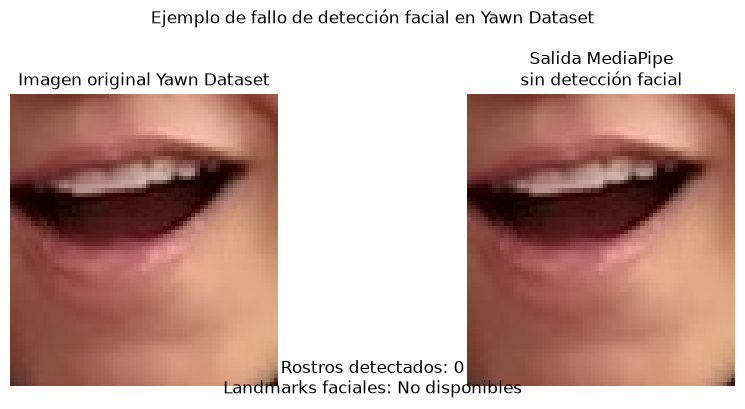

Rostros detectados: 0
Landmarks faciales: No disponibles


In [ ]:
rostros = len(resultado.face_landmarks)
texto = (
    f"Rostros detectados: {rostros}\n"
    "Landmarks faciales: No disponibles"
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(imagen_rgb)
plt.title("Imagen original Yawn Dataset")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(imagen_rgb)
plt.title(
    "Salida MediaPipe\nsin detección facial"
)
plt.axis("off")
plt.figtext(
    0.5,
    0.02,
    texto,
    ha="center",
    fontsize=12
)

plt.suptitle(
    "Ejemplo de fallo de detección facial en Yawn Dataset"
)
plt.tight_layout()
plt.savefig(
    "../results/fig_mediapipe_yawn_sin_rostro.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print(texto)